In [1]:
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from estimation_fct import *
from graph_format import *
import copy
from welfare_measures import *


# Load model
from model import ModelClass

model = ModelClass() 


In [2]:
par = model.par
sol = model.sol
sim = model.sim

# Load the model with calibrated values
theta_names = ("sigma", "gamma", "mu", "zeta", "gamma_1", "gamma_2")

par.N_a = 40
par.N_k = 40
par.N_s = 40

par.flexible_hours = "NVFI"
par.speed = "FAST"

theta_final = np.array([1.1964111575, 10.2412728324, 15.8236901476, 10.7796258438, 0.3064045126, 7.0725443884])

for i, name in enumerate(theta_names):
    setattr(model.par, name, theta_final[i])

efterloen_options = [1, 0]
flexible_hours_options = [par.flexible_hours, "Fixed"]

shares_efterloen = [0.32390004, 1 - 0.32390004]
shares_inflexible = [0.57511653, 1 - 0.57511653]


## Early retirement change

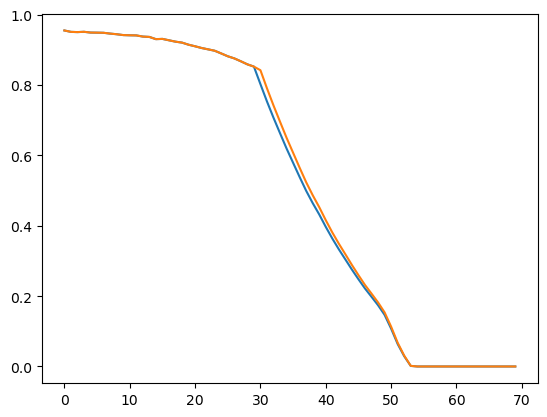

In [3]:

model.par.first_retirement = 30

model_og = copy.deepcopy(get_weighted_model(model, shares_efterloen, shares_inflexible, efterloen_options, flexible_hours_options))

model.par.first_retirement = 31

model_new = copy.deepcopy(get_weighted_model(model, shares_efterloen, shares_inflexible, efterloen_options, flexible_hours_options))

plt.plot(np.mean(model_og.sim.ex, axis=0))
plt.plot(np.mean(model_new.sim.ex, axis=0))
    

In [5]:
consumption_eq = find_consumption_equivalence(model_og, model_new, do_print= True, the_method = 'brentq')

print(consumption_eq)

Expected welfare  before parameter changes: -70.42896188272005
Expected welfare after parameter changes: -70.36418515948144
Consumption at every age before the policy change must change with 0.3 pct. to keep the same utility, and analytically: 73231.9 pct.
0.002852971660988496


## Payins

In [3]:

tau_1 = np.array([18.7 for i in range(par.T+1)]) / 100
tau_2 = np.arange(par.T+1)*0.3 / 100
tau_3 = 0.005*np.arange(par.T+1)**2 / 100

In [4]:


model_og = copy.deepcopy(get_weighted_model(model, shares_efterloen, shares_inflexible, efterloen_options, flexible_hours_options))


model.par.tau_private = tau_1 - par.tau_employer 
model_tau_1 = copy.deepcopy(get_weighted_model(model, shares_efterloen, shares_inflexible, efterloen_options, flexible_hours_options))
consumption_eq_tau_1 = find_consumption_equivalence(model_og, model_tau_1, do_print= True, the_method = 'brentq')

model.par.tau_private = tau_2 - par.tau_employer 
model_tau_2 = copy.deepcopy(get_weighted_model(model, shares_efterloen, shares_inflexible, efterloen_options, flexible_hours_options))
consumption_eq_tau_2 = find_consumption_equivalence(model_og, model_tau_2, do_print= True, the_method = 'brentq')

model.par.tau_private = tau_3 - par.tau_employer 
model_tau_3 = copy.deepcopy(get_weighted_model(model, shares_efterloen, shares_inflexible, efterloen_options, flexible_hours_options))
consumption_eq_tau_3 = find_consumption_equivalence(model_og, model_tau_3, do_print= True, the_method = 'brentq')

print("Consumption equivalence for tau_1: ", consumption_eq_tau_1)
print("Consumption equivalence for tau_2: ", consumption_eq_tau_2)
print("Consumption equivalence for tau_3: ", consumption_eq_tau_3)

Expected welfare  before parameter changes: -133.26185248353082
Expected welfare after parameter changes: -134.33692282489477
Consumption at every age before the policy change must change with -4.6 pct. to keep the same utility, and analytically: 79314635.0 pct.
Expected welfare  before parameter changes: -133.26185248353082
Expected welfare after parameter changes: -132.63635901766727
Consumption at every age before the policy change must change with 2.8 pct. to keep the same utility, and analytically: 97251488.5 pct.
Expected welfare  before parameter changes: -133.26185248353082
Expected welfare after parameter changes: -132.4521733104756
Consumption at every age before the policy change must change with 3.6 pct. to keep the same utility, and analytically: 99472384.5 pct.
Consumption equivalence for tau_1:  -0.045765098130492586
Consumption equivalence for tau_2:  0.02783544688017104
Consumption equivalence for tau_3:  0.03620803609766175


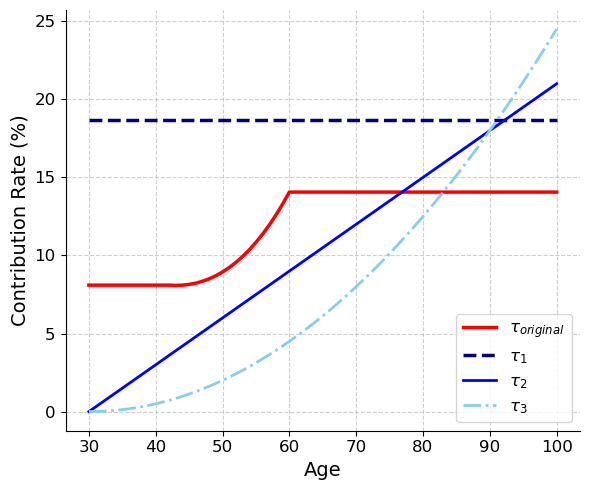

In [5]:
ages_tau = np.arange(30, 30 + par.T + 1)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(ages_tau, par.tau_employer * 100, color="red", linestyle="-", linewidth=2.5, label=r"$\tau_{original}$")
ax.plot(ages_tau, tau_1 * 100, color="navy", linestyle="--", linewidth=2.5, label=r"$\tau_1$")
ax.plot(ages_tau, tau_2 * 100, color="blue", linestyle="-", linewidth=2, label=r"$\tau_2$")
ax.plot(ages_tau, tau_3 * 100, color="skyblue", linestyle="-.", linewidth=2, label=r"$\tau_3$")

ax.set_xlabel("Age", fontsize=14)
ax.set_ylabel("Contribution Rate (%)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best", frameon=True, fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

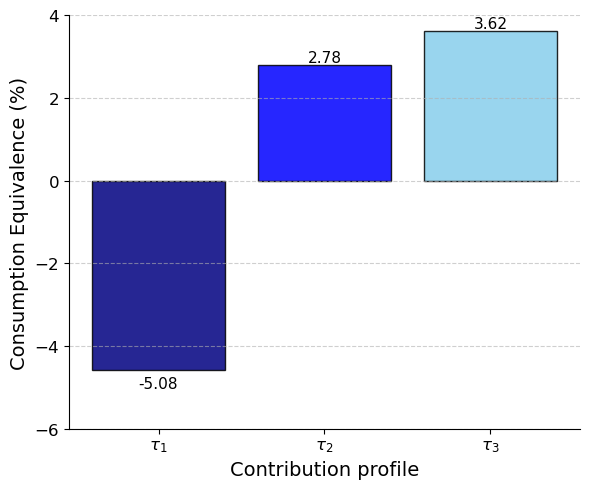

In [6]:
labels = [r"$\tau_1$", r"$\tau_2$", r"$\tau_3$"]
ce_values = np.array([
    consumption_eq_tau_1,
    consumption_eq_tau_2,
    consumption_eq_tau_3
]) * 100

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    labels,
    ce_values,
    color=["navy", "blue", "skyblue"],
    alpha=0.85,
    edgecolor="black"
)

ax.set_xlabel("Contribution profile", fontsize=14)
ax.set_ylabel("Consumption Equivalence (%)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(-6, 4)

for bar in bars:
    if bar.get_height() < 0:
        height = bar.get_height() - 0.5
    else:
        height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()